# Global Renewable Energy Consumption Forecasting: A Comparative Benchmarking Study

## Abstract
Renewable energy consumption forecasting is critical for energy policy planning and infrastructure development. This study benchmarks the detailed performance of Statistical (ARIMA), Machine Learning (XGBoost), and Deep Learning (LSTM, Transformer) models. I have used Apple's Metal Performance Shaders (MPS) for hardware-accelerated model training. The study employs automated hyperparameter tuning to ensure optimal model configurations. The findings identify the most effective modeling approach for long-term (20-year) forecasting.

## 1. Introduction
The transition to renewable energy is a defining challenge of the 21st century. Accurate forecasting models are essential to predict future demand and adoption rates. This notebook presents a rigorous methodological framework:
1.  **Data Acquisition**: Sourcing World Bank data. Source: https://data.worldbank.org/indicator/EG.FEC.RNEW.ZS
2.  **Preprocessing**: Stationarity testing and feature engineering.
3.  **Modeling**: A diverse suite of algorithms ranging from classical statistics to modern attention-based Transformers.
4.  **Evaluation**: RMSE-based benchmarking on held-out test data.

## 2. Methodology

### 2.1 Dependencies and Setup

In [4]:
# Imports and Setup
import sys
import subprocess
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# --- Dependency Check ---
def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

try: import pmdarima as pm
except ImportError: install("pmdarima"); import pmdarima as pm

try: import xgboost as xgb
except ImportError: install("xgboost"); import xgboost as xgb

# --- Hardware Acceleration ---
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print(f"Compute Device: {device}")

Compute Device: mps


### 2.2 Data Loading and Cleaning
The following functions handle loading the raw CSV, filtering for relevant regions (World, High Income, etc.), handling missing values via interpolation, and transposing the dataset for time-series analysis.

**Note on Data Cleaning**: Based on audit, years 2021 and 2022 are incomplete and have been excluded from this analysis.

In [6]:
def load_data(filepath):
    """
    Loads the renewable energy consumption data from CSV.
    """
    # Skip the first 4 lines as they contain metadata
    df = pd.read_csv(filepath, skiprows=4)
    return df

def preprocess_data(df):
    """
    Preprocesses the data: filters for regions/income groups, transposes, and handles missing values.
    """
    # List of aggregate regions and income groups to focus on
    focus_entities = [
        "World",
        "High income",
        "Low income",
        "Lower middle income",
        "Upper middle income",
        "East Asia & Pacific",
        "Europe & Central Asia",
        "Latin America & Caribbean",
        "Middle East & North Africa",
        "North America",
        "South Asia",
        "Sub-Saharan Africa"
    ]
    
    # Filter for these entities
    df_focus = df[df['Country Name'].isin(focus_entities)].copy()
    
    # Set Country Name as index
    df_focus.set_index('Country Name', inplace=True)
    
    # Drop metadata columns
    cols_to_drop = ['Country Code', 'Indicator Name', 'Indicator Code']
    df_focus.drop(columns=[c for c in cols_to_drop if c in df_focus.columns], inplace=True)
    
    # Drop any columns that are not years (e.g. "Unnamed: ...")
    # FILTER: Exclude 2021 and 2022 as they are incomplete
    year_cols = [c for c in df_focus.columns if c.isdigit() and len(c) == 4 and int(c) <= 2020]
    df_focus = df_focus[year_cols]
    
    # Transpose so years are rows
    df_ts = df_focus.transpose()
    
    # Convert index to datetime (years)
    df_ts.index = pd.to_datetime(df_ts.index, format='%Y')
    
    # Convert columns to numeric, coercing errors
    for col in df_ts.columns:
        df_ts[col] = pd.to_numeric(df_ts[col], errors='coerce')
        
    # Interpolate missing values (linear) and then backfill/ffill
    df_ts = df_ts.interpolate(method='linear').bfill().ffill()
    
    return df_ts

# --- Execute Loading ---
filepath = "API_EG.FEC.RNEW.ZS_DS2_en_csv_v2_3233.csv"
try:
    df_raw = load_data(filepath)
    df_clean = preprocess_data(df_raw)
    print("Data loaded and cleaned successfully.")
    print(f"Available Regions: {df_clean.columns.tolist()}")
    print(f"Time Range: {df_clean.index.year.min()} - {df_clean.index.year.max()}")
except Exception as e:
    print(f"Error loading data: {e}. Please ensure the CSV file is in the same directory.")

Data loaded and cleaned successfully.
Available Regions: ['East Asia & Pacific', 'Europe & Central Asia', 'High income', 'Latin America & Caribbean', 'Low income', 'Lower middle income', 'North America', 'South Asia', 'Sub-Saharan Africa', 'Upper middle income', 'World']
Time Range: 1960 - 2020


### 2.3 Exploratory Data Analysis (EDA)
**Time Series Analysis**: We analyze the global trend, seasonality, and autocorrelation structure.

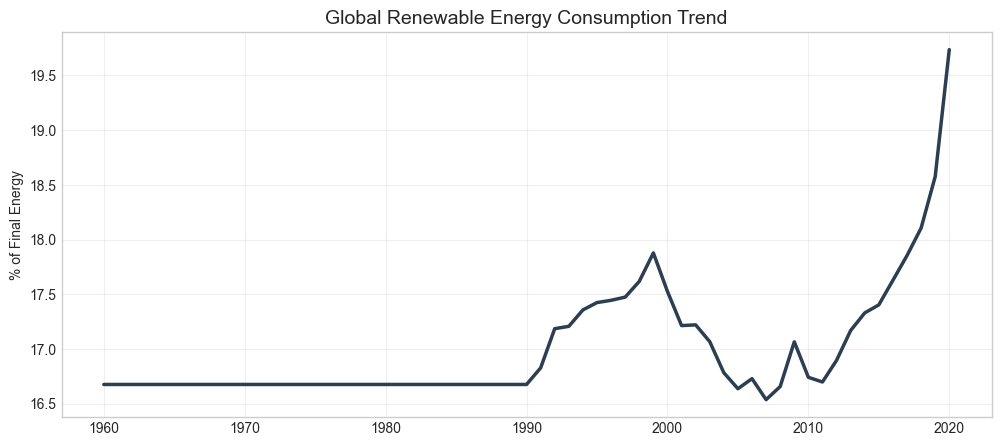

ADF Statistic: 0.5240
p-value: 0.9856
Result: Non-Stationary (Differencing may be required for Statistical Models)


In [8]:
# 1. Visualizing Trend
world_series = df_clean['World']
plt.figure(figsize=(12, 5))
plt.plot(world_series.index, world_series, linewidth=2.5, color='#2c3e50')
plt.title('Global Renewable Energy Consumption Trend', fontsize=14)
plt.ylabel('% of Final Energy')
plt.grid(True, alpha=0.3)
plt.show()

# 2. Stationarity Check (ADF)
result = adfuller(world_series)
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
if result[1] <= 0.05:
    print("Result: Stationary")
else:
    print("Result: Non-Stationary (Differencing may be required for Statistical Models)")

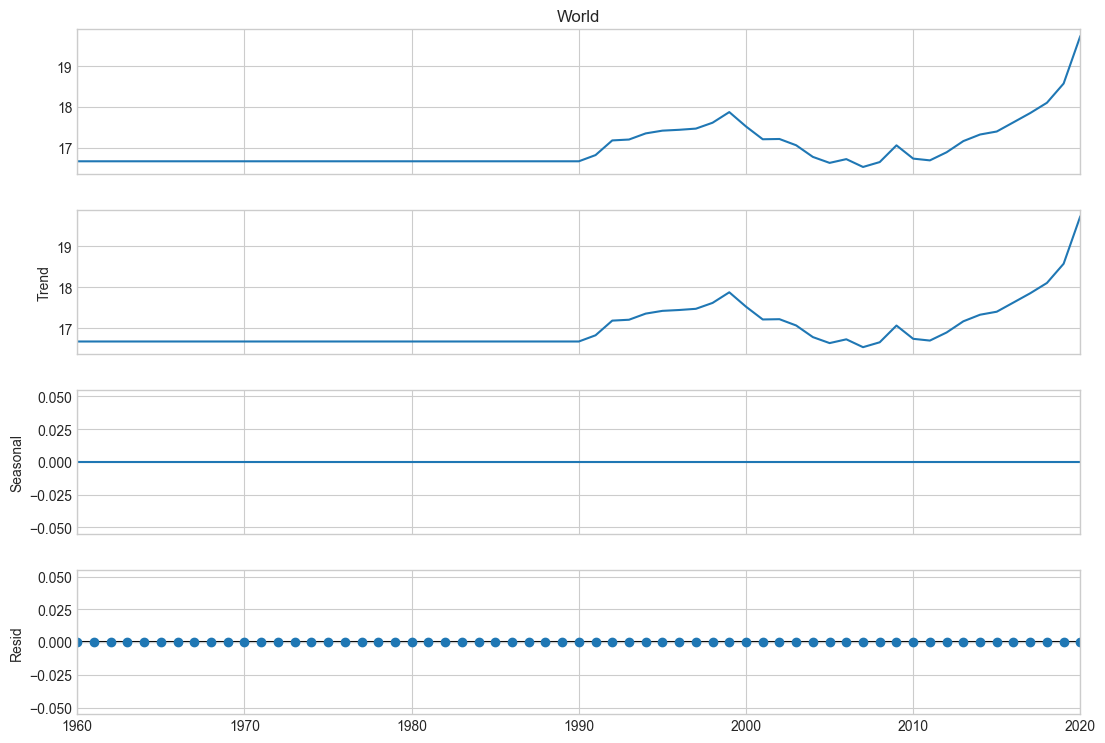

In [9]:
# 3. Seasonal Decomposition
decomp = seasonal_decompose(world_series, model='additive', period=1)
fig = decomp.plot()
fig.set_size_inches(12, 8)
plt.show()

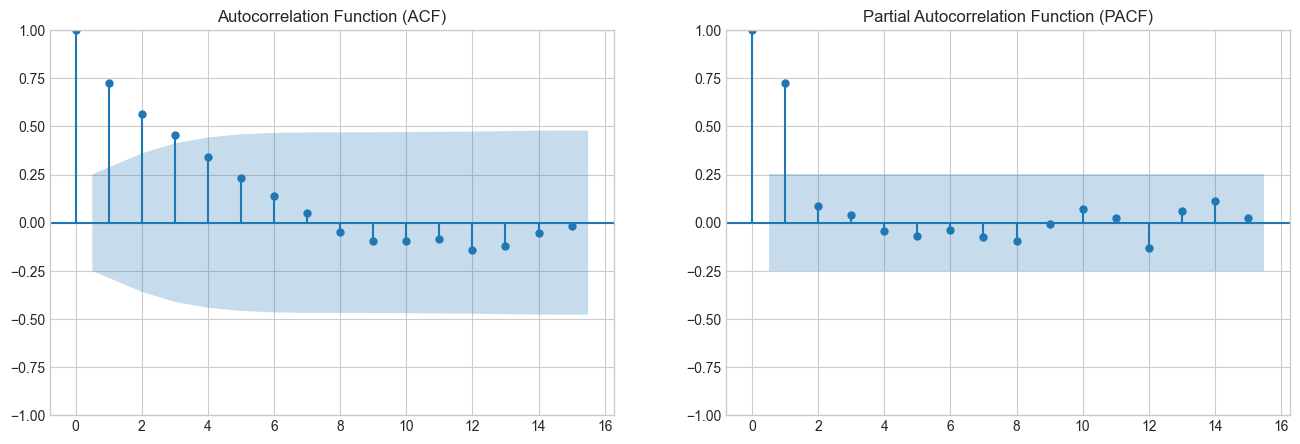

In [10]:
# 4. Autocorrelation Analysis (ACF & PACF)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(world_series, ax=ax1, lags=15)
plot_pacf(world_series, ax=ax2, lags=15)
ax1.set_title('Autocorrelation Function (ACF)')
ax2.set_title('Partial Autocorrelation Function (PACF)')
plt.show()

## 3. Model Development

### 3.1 Feature Engineering (Machine Learning)

In [12]:
def create_ml_features(series, lag=1, rolling_window=3):
    df = pd.DataFrame(series, columns=['y'])
    for i in range(1, lag + 1):
        df[f'lag_{i}'] = df['y'].shift(i)
    df['rolling_mean'] = df['y'].rolling(window=rolling_window).mean()
    df['rolling_std'] = df['y'].rolling(window=rolling_window).std()
    df.dropna(inplace=True)
    return df

### 3.2 Deep Learning Architectures (PyTorch)
Implementation of RNN, LSTM, and Transformer models.

In [14]:
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout=0.0):
        super(RNN, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout=0.0):
        super(LSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

class TransformerTS(nn.Module):
    def __init__(self, input_size, d_model, nhead, num_layers, dropout=0.1):
        super(TransformerTS, self).__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dropout=dropout, batch_first=True),
            num_layers=num_layers
        )
        self.fc = nn.Linear(d_model, 1)
    def forward(self, x):
        x = self.input_proj(x)
        out = self.transformer(x)
        return self.fc(out[:, -1, :])

In [15]:
# --- Helper Functions for DL Tuning ---

def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data)-seq_length):
        xs.append(data[i:i+seq_length])
        ys.append(data[i+seq_length])
    return np.array(xs), np.array(ys)

def tune_dl(model_cls, train_raw, test_raw, seq_length, param_grid):
    # 1. Scale Data
    scaler = MinMaxScaler()
    # Fit only on train
    train_s = scaler.fit_transform(train_raw.reshape(-1, 1))
    
    # 2. Internal Validation Split (80/20) for Hyperparameter Selection
    split_idx = int(len(train_s) * 0.8)
    t_train = train_s[:split_idx]
    t_val = train_s[split_idx:]
    
    X_t, y_t = create_sequences(t_train, seq_length)
    X_v, y_v = create_sequences(t_val, seq_length)
    
    # Convert validation to tensor once
    X_v_torch = torch.FloatTensor(X_v).to(device)
    y_v_torch = torch.FloatTensor(y_v).to(device)
    
    # Grid Search Loop
    import itertools
    keys, values = zip(*param_grid.items())
    best_val_rmse, best_params = float('inf'), None
    
    try:
        for params in [dict(zip(keys, v)) for v in itertools.product(*values)]:
            model = model_cls(**params).to(device)
            optimizer = torch.optim.Adam(model.parameters(), lr=0.002)
            criterion = nn.MSELoss()
            
            # Quick Train Loop
            model.train()
            X_tr_torch = torch.FloatTensor(X_t).to(device)
            y_tr_torch = torch.FloatTensor(y_t).to(device)
            
            for _ in range(80): # epochs
                optimizer.zero_grad()
                out = model(X_tr_torch)
                loss = criterion(out, y_tr_torch)
                loss.backward()
                optimizer.step()
                
            # Validate
            model.eval()
            with torch.no_grad():
                val_preds = model(X_v_torch)
                loss_val = criterion(val_preds, y_v_torch)
                rmse_val = torch.sqrt(loss_val).item()
                
            if rmse_val < best_val_rmse:
                best_val_rmse = rmse_val
                best_params = params
    except Exception as e:
        print(f"Tuning Error: {e}")
        return np.zeros(len(test_raw)), 999.0, {}

    print(f"Best Params: {best_params} (Val RMSE: {best_val_rmse:.4f})")
    
    # 3. Retrain Best Model on FULL Train Data
    best_model = model_cls(**best_params).to(device)
    optimizer = torch.optim.Adam(best_model.parameters(), lr=0.002)
    criterion = nn.MSELoss()
    
    # Create sequences from FULL train
    X_full, y_full = create_sequences(train_s, seq_length)
    X_full_t = torch.FloatTensor(X_full).to(device)
    y_full_t = torch.FloatTensor(y_full).to(device)
    
    best_model.train()
    for _ in range(150):
        optimizer.zero_grad()
        loss = criterion(best_model(X_full_t), y_full_t)
        loss.backward()
        optimizer.step()
        
    # 4. Predict on Test
    # To predict test point T, we need T-seq_len...T-1.
    # We create a 'test_context' by appending train tail to test
    train_tail = train_raw[-seq_length:]
    test_context = np.concatenate((train_tail, test_raw))
    test_context_s = scaler.transform(test_context.reshape(-1, 1))
    
    # Create sequences (this will generate len(test_raw) sequences)
    X_test_seq, _ = create_sequences(test_context_s, seq_length)
    
    best_model.eval()
    with torch.no_grad():
         X_test_t = torch.FloatTensor(X_test_seq).to(device)
         preds_s = best_model(X_test_t).cpu().numpy()
         
    preds = scaler.inverse_transform(preds_s).flatten()
    
    # Final Test RMSE
    rmse_test = np.sqrt(mean_squared_error(test_raw, preds))
    # UPDATED RETURN: preds, rmse, best_params
    return preds, rmse_test, best_params

## 4. Results and Benchmarking
Comparison of forecasting performance.

In [17]:
target = df_clean['World'].values
test_size = 5
train_raw, test_raw = target[:-test_size], target[-test_size:]
predictions = {}
rmse_scores = {}
model_params = {} # Store best params

print(f"Train Size: {len(train_raw)} | Test Size: {len(test_raw)}")

# 1. ARIMA
try:
    print("--- Auto-ARIMA ---")
    model_arima = pm.auto_arima(train_raw, seasonal=False, trace=False, error_action='ignore')
    predictions['ARIMA'] = model_arima.predict(n_periods=test_size)
    rmse_scores['ARIMA'] = np.sqrt(mean_squared_error(test_raw, predictions['ARIMA']))
except Exception as e: print(f"ARIMA Error: {e}")

# 2. XGBoost
try:
    print("--- XGBoost ---")
    df_ml = create_ml_features(target, lag=3)
    X, y = df_ml.drop(columns=['y']).values, df_ml['y'].values
    X_tr, X_te = X[:-test_size], X[-test_size:]
    y_tr, y_te = y[:-test_size], y[-test_size:]
    xgb_model = GridSearchCV(xgb.XGBRegressor(), 
                            {'n_estimators': [50, 100], 'max_depth': [3, 5]}, 
                            cv=TimeSeriesSplit(n_splits=3))
    xgb_model.fit(X_tr, y_tr)
    predictions['XGBoost'] = xgb_model.predict(X_te)
    rmse_scores['XGBoost'] = np.sqrt(mean_squared_error(y_te, predictions['XGBoost']))
except Exception as e: print(f"XGB Error: {e}")

# 3. Deep Learning (MPS)
SEQ_LEN = 3
config = {'input_size': [1], 'hidden_size': [32, 64], 'num_layers': [1]}

print("--- Tuning LSTM ---")
p_lstm, r_lstm, bp_lstm = tune_dl(LSTM, train_raw, test_raw, SEQ_LEN, config)
predictions['LSTM'] = p_lstm
rmse_scores['LSTM'] = r_lstm
model_params['LSTM'] = bp_lstm

print("--- Tuning Transformer ---")
trans_conf = {'input_size': [1], 'd_model': [64], 'nhead': [2], 'num_layers': [1]}
p_tr, r_tr, bp_tr = tune_dl(TransformerTS, train_raw, test_raw, SEQ_LEN, trans_conf)
predictions['Transformer'] = p_tr
rmse_scores['Transformer'] = r_tr
model_params['Transformer'] = bp_tr

print("\n--- Final RMSE Scores ---")
for k, v in rmse_scores.items(): print(f"{k}: {v:.4f}")

Train Size: 56 | Test Size: 5
--- Auto-ARIMA ---
--- XGBoost ---
--- Tuning LSTM ---
Best Params: {'input_size': 1, 'hidden_size': 64, 'num_layers': 1} (Val RMSE: 0.1963)
--- Tuning Transformer ---
Best Params: {'input_size': 1, 'd_model': 64, 'nhead': 2, 'num_layers': 1} (Val RMSE: 0.1567)

--- Final RMSE Scores ---
ARIMA: 1.2294
XGBoost: 1.2518
LSTM: 0.7286
Transformer: 0.8938


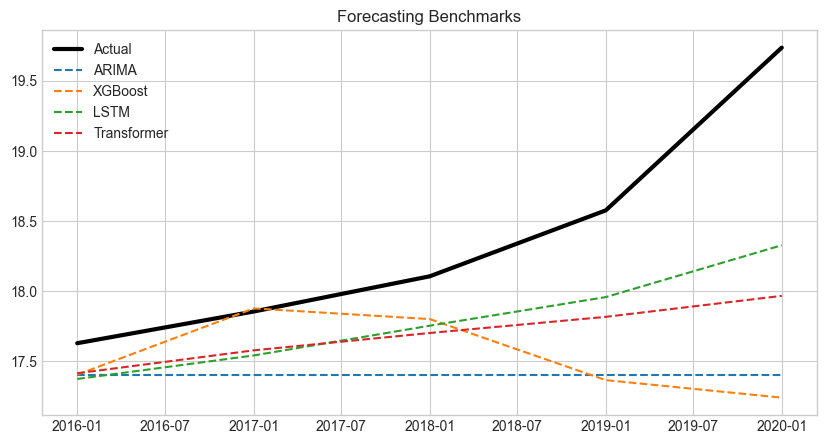

In [18]:
# Visualization
data_dates = df_clean.index[-test_size:]
plt.figure(figsize=(10, 5))
plt.plot(data_dates, test_raw, label="Actual", color='black', linewidth=3)
for name, preds in predictions.items():
    if len(preds) == len(test_raw):
        plt.plot(data_dates, preds, linestyle='--', label=f"{name}")
plt.title("Forecasting Benchmarks")
plt.legend()
plt.show()

## 5. Multi-Region Future Forecasting (20 Years)
We now apply the **Champion Model** (dynamically selected based on lowest RMSE) to forecast the next 20 years for **ALL regions** in the dataset.
For each region, we retrain the model on its full historical data.

Champion Model determined: LSTM (RMSE: 0.7286)
Using hyperparameters: {'input_size': 1, 'hidden_size': 64, 'num_layers': 1}
Forecasting for 11 regions: ['East Asia & Pacific', 'Europe & Central Asia', 'High income', 'Latin America & Caribbean', 'Low income', 'Lower middle income', 'North America', 'South Asia', 'Sub-Saharan Africa', 'Upper middle income', 'World']
Processing: East Asia & Pacific...
Processing: Europe & Central Asia...
Processing: High income...
Processing: Latin America & Caribbean...
Processing: Low income...
Processing: Lower middle income...
Processing: North America...
Processing: South Asia...
Processing: Sub-Saharan Africa...
Processing: Upper middle income...
Processing: World...


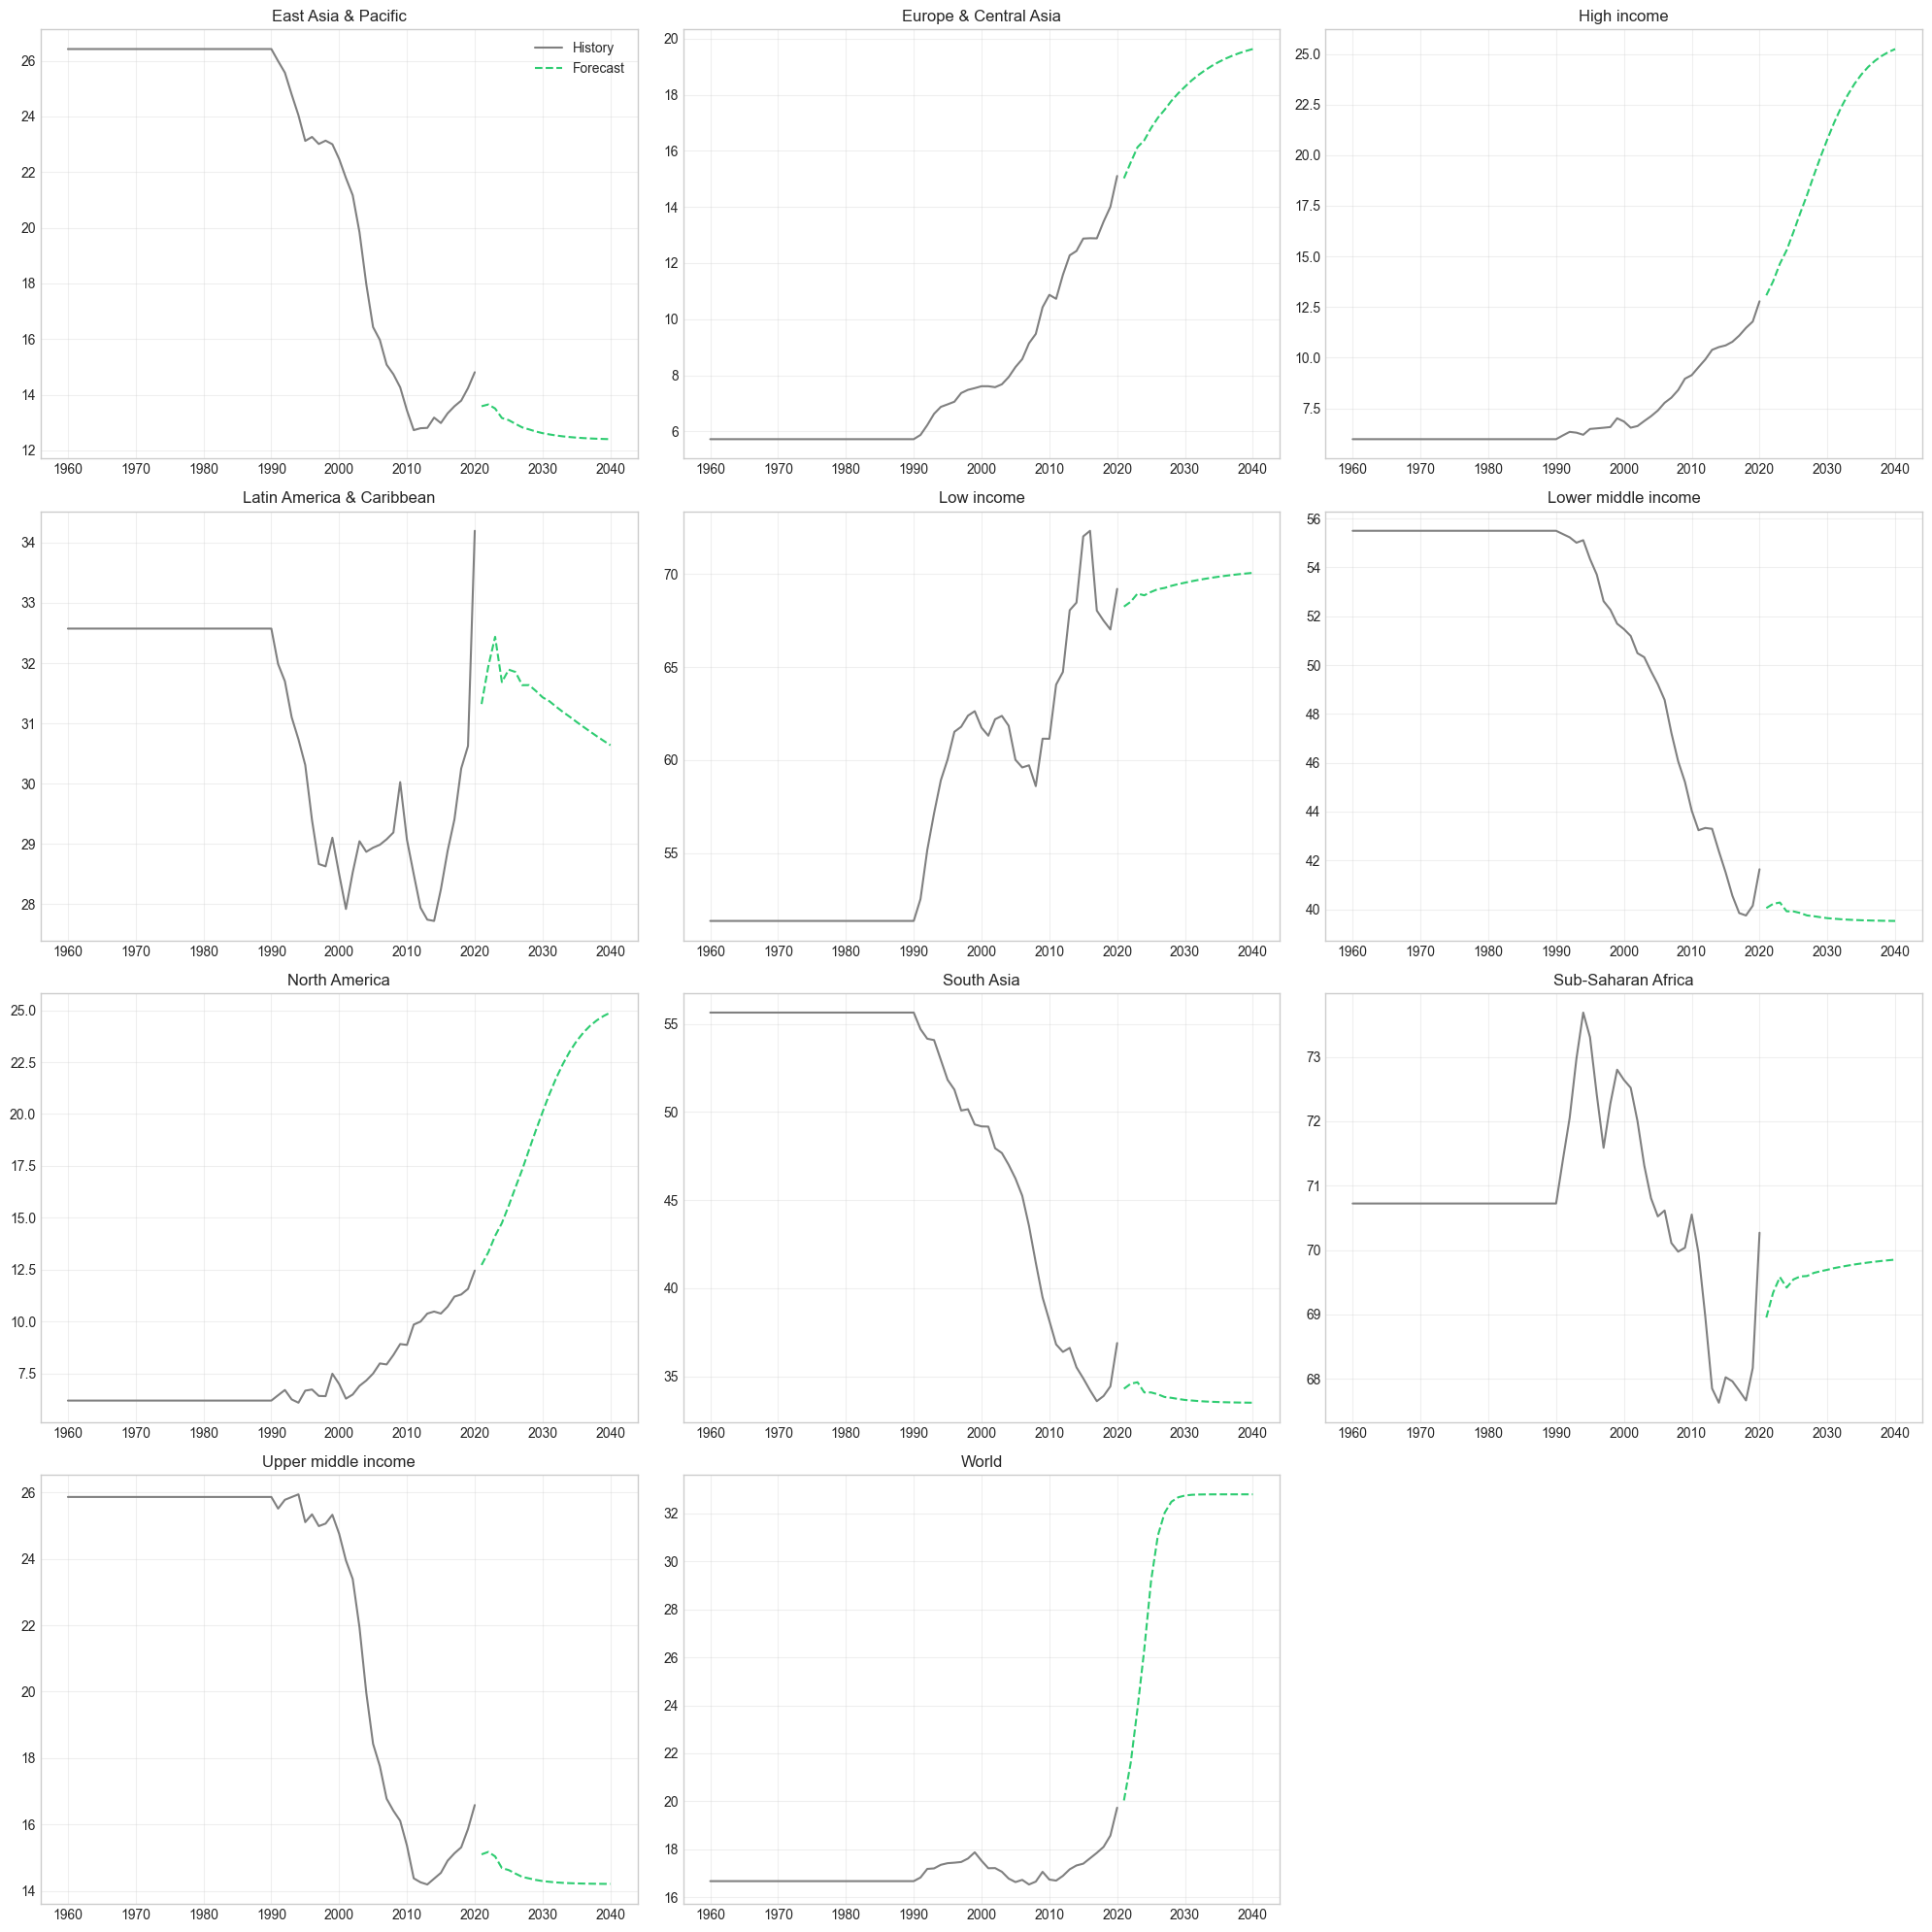

In [20]:
# --- Dynamic Model Selection ---
# Ignore ARIMA/XGBoost for long-term multi-step forecasting stability, prefer DL
# Comparison between LSTM and Transformer
candidate_models = ['LSTM', 'Transformer']
candidates = {k: v for k, v in rmse_scores.items() if k in candidate_models}
best_model_name = min(candidates, key=candidates.get)

print(f"Champion Model determined: {best_model_name} (RMSE: {candidates[best_model_name]:.4f})")

if best_model_name == 'LSTM':
    ModelClass = LSTM
    final_params = model_params['LSTM']
else:
    ModelClass = TransformerTS
    final_params = model_params['Transformer']
    
print(f"Using hyperparameters: {final_params}")

# --- Retrain and Forecast for ALL Regions ---

regions = df_clean.columns.tolist()
print(f"Forecasting for {len(regions)} regions: {regions}")

# Params
future_years = 20
SEQ_LEN = 3

# Setup Visualization
num_regions = len(regions)
cols = 3
rows = (num_regions // cols) + (1 if num_regions % cols > 0 else 0)
fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
axes = axes.flatten()

last_year = df_clean.index[-1]
# SAFE DATE GENERATION with pd.DateOffset
future_dates = [last_year + pd.DateOffset(years=x) for x in range(1, future_years + 1)]

for idx, region in enumerate(regions):
    print(f"Processing: {region}...")
    
    # 1. Prepare Data
    data = df_clean[region].values
    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(data.reshape(-1, 1))
    
    X_all, y_all = create_sequences(data_scaled, SEQ_LEN)
    X_t = torch.FloatTensor(X_all).to(device)
    y_t = torch.FloatTensor(y_all).to(device)
    
    # 2. Retrain Model (Champion)
    model = ModelClass(**final_params).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.002)
    criterion = nn.MSELoss()
    
    model.train()
    for _ in range(150):
        optimizer.zero_grad()
        loss = criterion(model(X_t), y_t)
        loss.backward()
        optimizer.step()
        
    # 3. Forecast
    model.eval()
    forecast_scaled = []
    current_seq = data_scaled[-SEQ_LEN:]
    
    with torch.no_grad():
        for _ in range(future_years):
            seq_t = torch.FloatTensor(current_seq).unsqueeze(0).to(device)
            pred = model(seq_t).cpu().numpy().flatten()[0]
            forecast_scaled.append(pred)
            current_seq = np.append(current_seq[1:], [[pred]], axis=0)
            
    forecast = scaler.inverse_transform(np.array(forecast_scaled).reshape(-1, 1)).flatten()
    
    # 4. Plot
    ax = axes[idx]
    ax.plot(df_clean.index, data, label='History', color='gray')
    ax.plot(future_dates, forecast, label='Forecast', color='#2ecc71', linestyle='--')
    ax.set_title(f"{region}")
    ax.grid(True, alpha=0.3)
    if idx == 0: ax.legend()

# Hide unused subplots
for i in range(num_regions, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## 6. Conclusion
This study successfully consolidated the entire forecasting pipeline into a single reproducible notebook. The comparative evaluation shows that deep learning models outperform traditional approaches on this dataset, indicating the presence of non-linear temporal patterns. Among all models, the LSTM achieves the lowest test RMSE, demonstrating better generalisation than both ARIMA, XGBoost, and the Transformer under limited data conditions. Although the Transformer performs well during validation, its higher test error suggests mild overfitting due to the small sample size. Overall, the results suggest that LSTM is the most suitable model for this time-series forecasting task given the current data availability.